In [1]:
# ============================================================
# SETUP - Run this cell first!
# ============================================================
#
# Before running this notebook, authenticate with Google:
#
#   In your terminal, run:
#   gcloud auth application-default login
#
# Then Run All Cells.
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.cloud import bigquery

import plotly.express as px
import plotly.graph_objects as go

sns.set_theme(
    style="whitegrid",
    palette="deep",
    font_scale=1.1
)

PROJECT = "ai-adoption-pipeline"
DATASET    = "ai_adoption_dw"

# Initialize client (uses your Gmail login automatically)
client = bigquery.Client(project=PROJECT)

def query(sql):
    """Run a BigQuery SQL query and return a DataFrame."""
    return client.query(sql).to_dataframe()

print(f"✅ Connected to BigQuery: {PROJECT}")
print(f"✅ Dataset: {DATASET}")

✅ Connected to BigQuery: ai-adoption-pipeline
✅ Dataset: ai_adoption_dw


In [2]:
# ============================================================
# EDA Analysis - AI Adoption & Workforce Impact
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.cloud import bigquery

PROJECT_ID = "ai-adoption-pipeline"
DATASET    = "ai_adoption_dw"

client = bigquery.Client(project=PROJECT_ID)

def query(sql):
    return client.query(sql).to_dataframe()

print(f"✅ Connected to BigQuery: {PROJECT_ID}")
print(f"✅ Dataset: {DATASET}")

✅ Connected to BigQuery: ai-adoption-pipeline
✅ Dataset: ai_adoption_dw


In [3]:
# ============================================================
# SECTION 1: Dataset Overview
# ============================================================

overview = query(f"""
    select
        count(*)                        as total_records,
        count(distinct company_key)     as unique_companies,
        count(distinct date_key)        as unique_time_periods,
        round(avg(productivity_change_percent), 2) as avg_productivity_change,
        round(avg(revenue_growth_percent), 2)      as avg_revenue_growth,
        round(avg(ai_roi_index), 2)                as avg_ai_roi_index,
        sum(jobs_displaced)             as total_jobs_displaced,
        sum(jobs_created)               as total_jobs_created,
        sum(net_jobs_change)            as total_net_jobs_change
    from `{PROJECT}.{DATASET}.fact_ai_survey`
""")

print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
display(overview.T.rename(columns={0: "value"}))

/home/jonyling/ai-adoption-pipeline/venv/lib/python3.11/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


DATASET OVERVIEW


,value
total_records,150000
unique_companies,10000
unique_time_periods,16
avg_productivity_change,9.27
avg_revenue_growth,4.61
avg_ai_roi_index,1.14
total_jobs_displaced,16705476
total_jobs_created,17682376
total_net_jobs_change,976900


/home/jonyling/ai-adoption-pipeline/venv/lib/python3.11/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


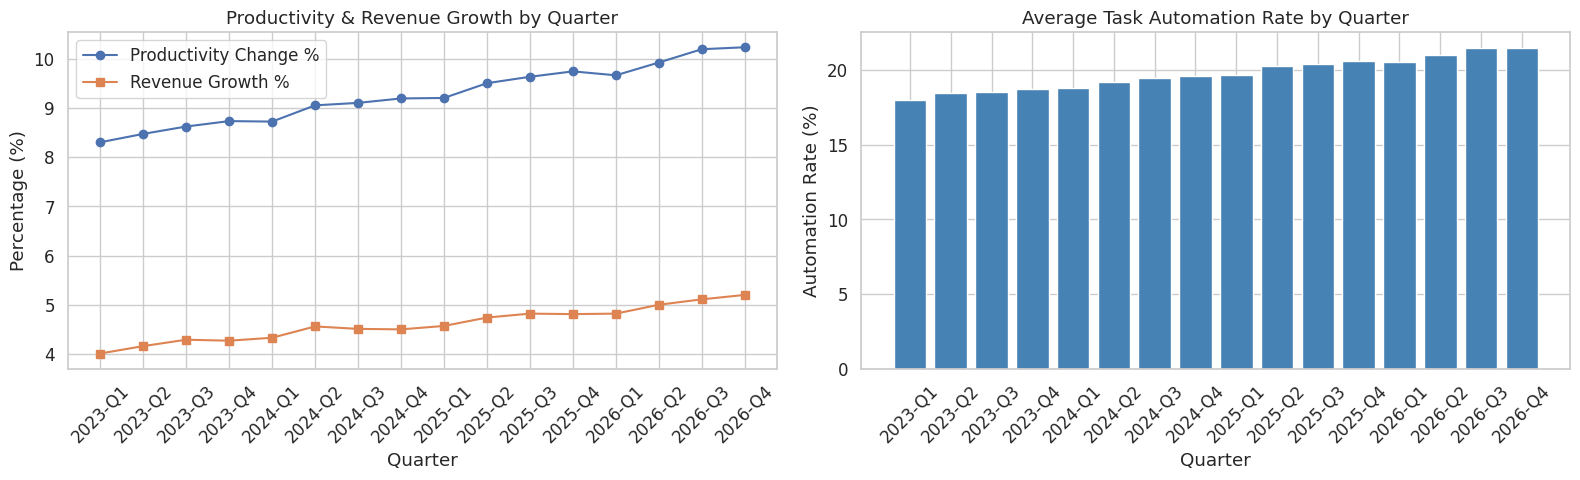

In [4]:
# ============================================================
# KPI 1: Quarterly Trends
# ============================================================

quarterly = query(f"""
    select
        d.year_quarter,
        d.survey_year,
        d.quarter,
        round(avg(f.productivity_change_percent), 2) as avg_productivity,
        round(avg(f.revenue_growth_percent), 2)      as avg_revenue_growth,
        round(avg(f.cost_reduction_percent), 2)      as avg_cost_reduction,
        round(avg(f.task_automation_rate), 2)         as avg_automation_rate
    from `{PROJECT}.{DATASET}.fact_ai_survey` f
    join `{PROJECT}.{DATASET}.dim_date` d on f.date_key = d.date_key
    group by d.year_quarter, d.survey_year, d.quarter
    order by d.survey_year, d.quarter
""")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Chart 1: Productivity & Revenue Growth over time
axes[0].plot(quarterly["year_quarter"], quarterly["avg_productivity"],
             marker="o", label="Productivity Change %")
axes[0].plot(quarterly["year_quarter"], quarterly["avg_revenue_growth"],
             marker="s", label="Revenue Growth %")
axes[0].set_title("Productivity & Revenue Growth by Quarter")
axes[0].set_xlabel("Quarter")
axes[0].set_ylabel("Percentage (%)")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend()

# Chart 2: Task Automation Rate over time
axes[1].bar(quarterly["year_quarter"], quarterly["avg_automation_rate"],
            color="steelblue")
axes[1].set_title("Average Task Automation Rate by Quarter")
axes[1].set_xlabel("Quarter")
axes[1].set_ylabel("Automation Rate (%)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("../docs/quarterly_trends.png", dpi=150)
plt.show()

/tmp/ipykernel_887/3339408867.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_887/3339408867.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


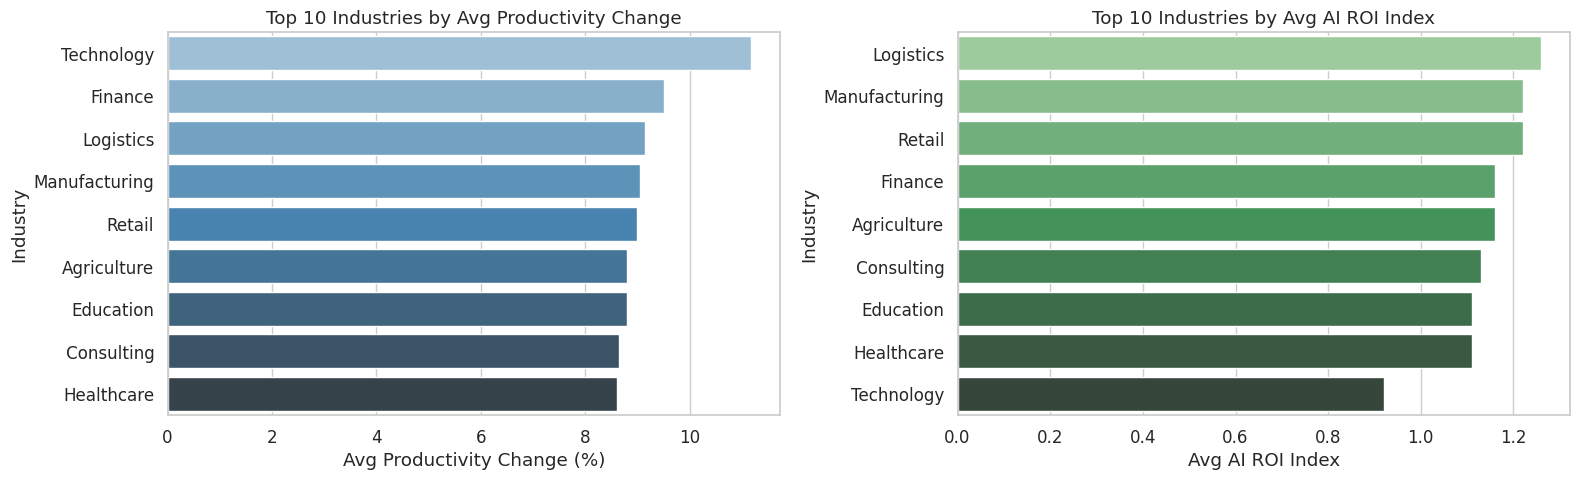

,industry,avg_productivity,avg_revenue_growth,avg_roi,avg_automation,record_count
0,Technology,11.17,5.63,0.92,21.59,21107
1,Finance,9.50,4.83,1.16,19.69,20166
2,Logistics,9.13,4.48,1.26,21.23,12961
3,Manufacturing,9.05,4.42,1.22,21.04,17501
4,Retail,8.99,4.46,1.22,21.03,16377
5,Agriculture,8.80,4.39,1.16,18.36,15570
6,Education,8.79,4.31,1.11,18.19,15172
7,Consulting,8.65,4.30,1.13,18.03,12504
8,Healthcare,8.60,4.23,1.11,18.06,18642


In [5]:
# ============================================================
# KPI 2: Top Industries by AI Performance
# ============================================================

industry = query(f"""
    select
        c.industry,
        round(avg(f.productivity_change_percent), 2) as avg_productivity,
        round(avg(f.revenue_growth_percent), 2)      as avg_revenue_growth,
        round(avg(f.ai_roi_index), 2)                as avg_roi,
        round(avg(f.task_automation_rate), 2)         as avg_automation,
        count(*) as record_count
    from `{PROJECT}.{DATASET}.fact_ai_survey` f
    join `{PROJECT}.{DATASET}.dim_company` c on f.company_key = c.company_key
    group by c.industry
    order by avg_productivity desc
""")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Chart 1: Productivity by Industry
sns.barplot(
    data=industry.head(10),
    x="avg_productivity",
    y="industry",
    ax=axes[0],
    palette="Blues_d"
)
axes[0].set_title("Top 10 Industries by Avg Productivity Change")
axes[0].set_xlabel("Avg Productivity Change (%)")
axes[0].set_ylabel("Industry")

# Chart 2: AI ROI by Industry
sns.barplot(
    data=industry.sort_values("avg_roi", ascending=False).head(10),
    x="avg_roi",
    y="industry",
    ax=axes[1],
    palette="Greens_d"
)
axes[1].set_title("Top 10 Industries by Avg AI ROI Index")
axes[1].set_xlabel("Avg AI ROI Index")
axes[1].set_ylabel("Industry")

plt.tight_layout()
plt.savefig("../docs/industry_analysis.png", dpi=150)
plt.show()

display(industry)

/home/jonyling/ai-adoption-pipeline/venv/lib/python3.11/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(
/tmp/ipykernel_887/3913405502.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


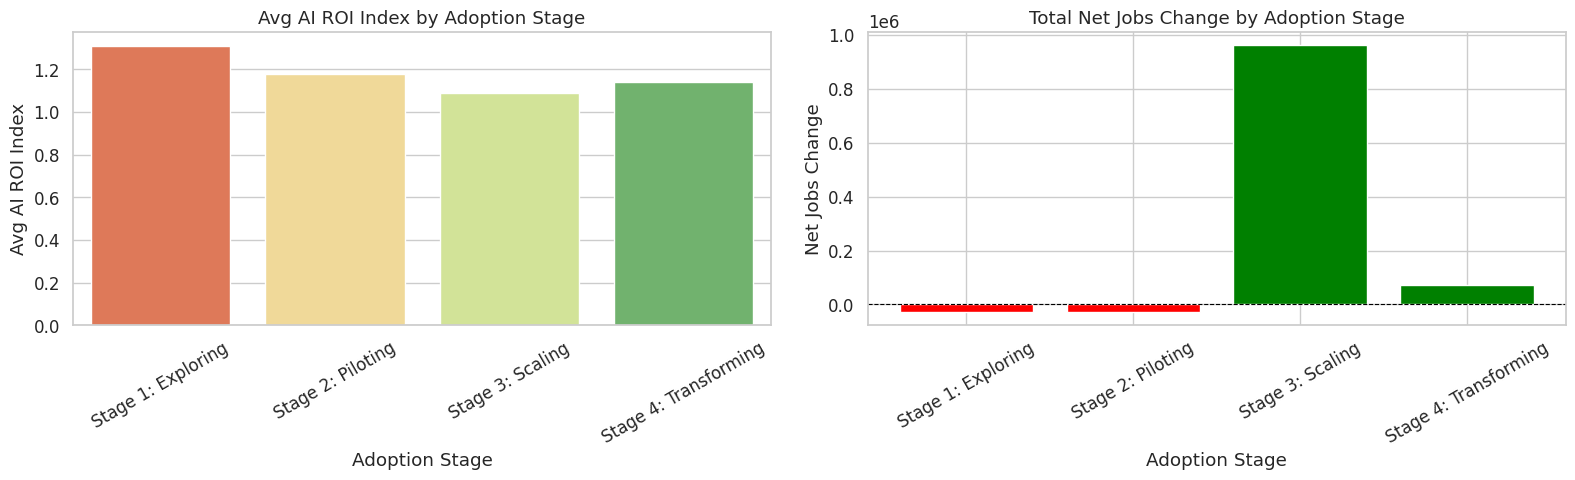

,stage_label,stage_order,num_companies,avg_productivity,avg_revenue_growth,avg_roi,avg_automation,total_net_jobs
0,Stage 1: Exploring,1,2362,2.39,0.50,1.31,6.24,-27759
1,Stage 2: Piloting,2,9152,6.17,2.89,1.18,14.81,-28222
2,Stage 3: Scaling,3,9518,12.03,6.15,1.09,24.33,961591
3,Stage 4: Transforming,4,962,19.79,10.49,1.14,36.94,71290


In [6]:
# ============================================================
# KPI 3: Company Segmentation by AI Adoption Stage
# ============================================================

segmentation = query(f"""
    select
        s.stage_label,
        s.stage_order,
        count(distinct f.company_key)                as num_companies,
        round(avg(f.productivity_change_percent), 2) as avg_productivity,
        round(avg(f.revenue_growth_percent), 2)      as avg_revenue_growth,
        round(avg(f.ai_roi_index), 2)                as avg_roi,
        round(avg(f.task_automation_rate), 2)         as avg_automation,
        sum(f.net_jobs_change)                        as total_net_jobs
    from `{PROJECT}.{DATASET}.fact_ai_survey` f
    join `{PROJECT}.{DATASET}.dim_ai_adoption_stage` s on f.stage_key = s.stage_key
    group by s.stage_label, s.stage_order
    order by s.stage_order
""")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Chart 1: Avg ROI by Adoption Stage
sns.barplot(
    data=segmentation,
    x="stage_label",
    y="avg_roi",
    ax=axes[0],
    palette="RdYlGn"
)
axes[0].set_title("Avg AI ROI Index by Adoption Stage")
axes[0].set_xlabel("Adoption Stage")
axes[0].set_ylabel("Avg AI ROI Index")
axes[0].tick_params(axis="x", rotation=30)

# Chart 2: Net Jobs Change by Adoption Stage
colors = ["red" if x < 0 else "green" for x in segmentation["total_net_jobs"]]
axes[1].bar(segmentation["stage_label"], segmentation["total_net_jobs"], color=colors)
axes[1].set_title("Total Net Jobs Change by Adoption Stage")
axes[1].set_xlabel("Adoption Stage")
axes[1].set_ylabel("Net Jobs Change")
axes[1].tick_params(axis="x", rotation=30)
axes[1].axhline(y=0, color="black", linestyle="--", linewidth=0.8)

plt.tight_layout()
plt.savefig("../docs/adoption_stage_segmentation.png", dpi=150)
plt.show()

display(segmentation)

/home/jonyling/ai-adoption-pipeline/venv/lib/python3.11/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


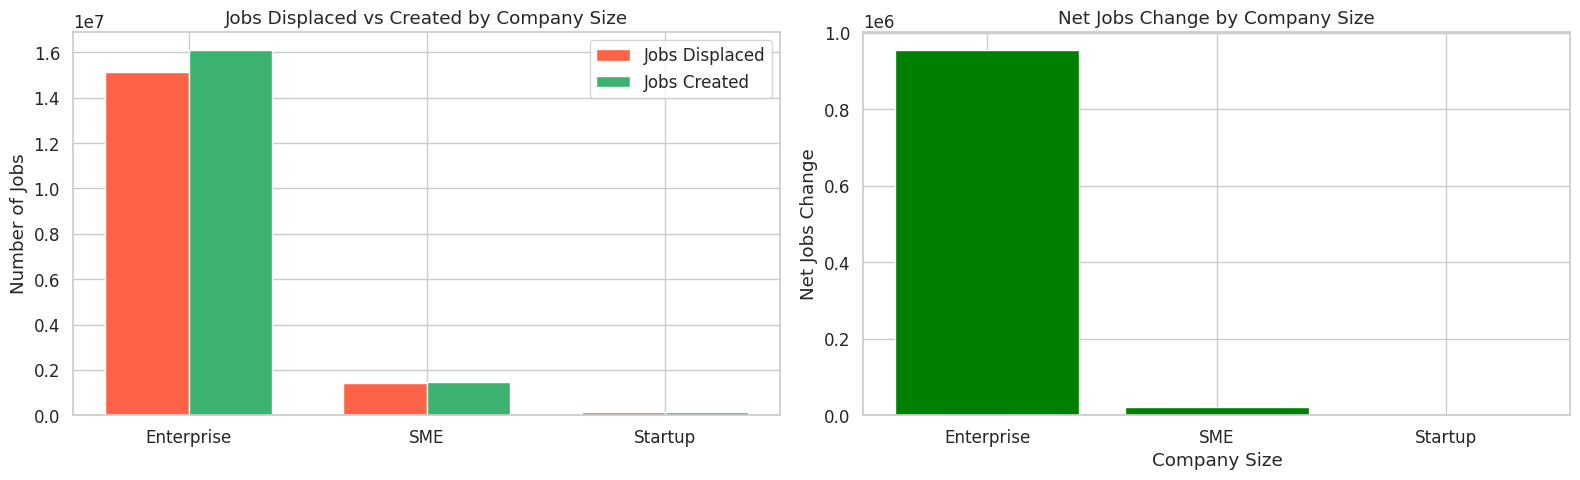

,company_size,total_displaced,total_created,net_change,avg_automation
0,Enterprise,15144622,16099067,954445,22.65
1,SME,1432758,1454693,21935,19.02
2,Startup,128096,128616,520,19.10


In [7]:
# ============================================================
# KPI 4: Workforce Impact Analysis
# ============================================================

workforce = query(f"""
    select
        c.company_size,
        sum(f.jobs_displaced)    as total_displaced,
        sum(f.jobs_created)      as total_created,
        sum(f.net_jobs_change)   as net_change,
        round(avg(f.task_automation_rate), 2) as avg_automation
    from `{PROJECT}.{DATASET}.fact_ai_survey` f
    join `{PROJECT}.{DATASET}.dim_company` c on f.company_key = c.company_key
    group by c.company_size
    order by total_displaced desc
""")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Chart 1: Jobs displaced vs created by company size
x = range(len(workforce))
width = 0.35
axes[0].bar([i - width/2 for i in x], workforce["total_displaced"],
            width, label="Jobs Displaced", color="tomato")
axes[0].bar([i + width/2 for i in x], workforce["total_created"],
            width, label="Jobs Created", color="mediumseagreen")
axes[0].set_title("Jobs Displaced vs Created by Company Size")
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(workforce["company_size"])
axes[0].set_ylabel("Number of Jobs")
axes[0].legend()

# Chart 2: Net jobs change by company size
colors = ["red" if v < 0 else "green" for v in workforce["net_change"]]
axes[1].bar(workforce["company_size"], workforce["net_change"], color=colors)
axes[1].set_title("Net Jobs Change by Company Size")
axes[1].set_xlabel("Company Size")
axes[1].set_ylabel("Net Jobs Change")
axes[1].axhline(y=0, color="black", linestyle="--", linewidth=0.8)

plt.tight_layout()
plt.savefig("../docs/workforce_impact.png", dpi=150)
plt.show()

display(workforce)

/home/jonyling/ai-adoption-pipeline/venv/lib/python3.11/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(
/tmp/ipykernel_887/3890808226.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_887/3890808226.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


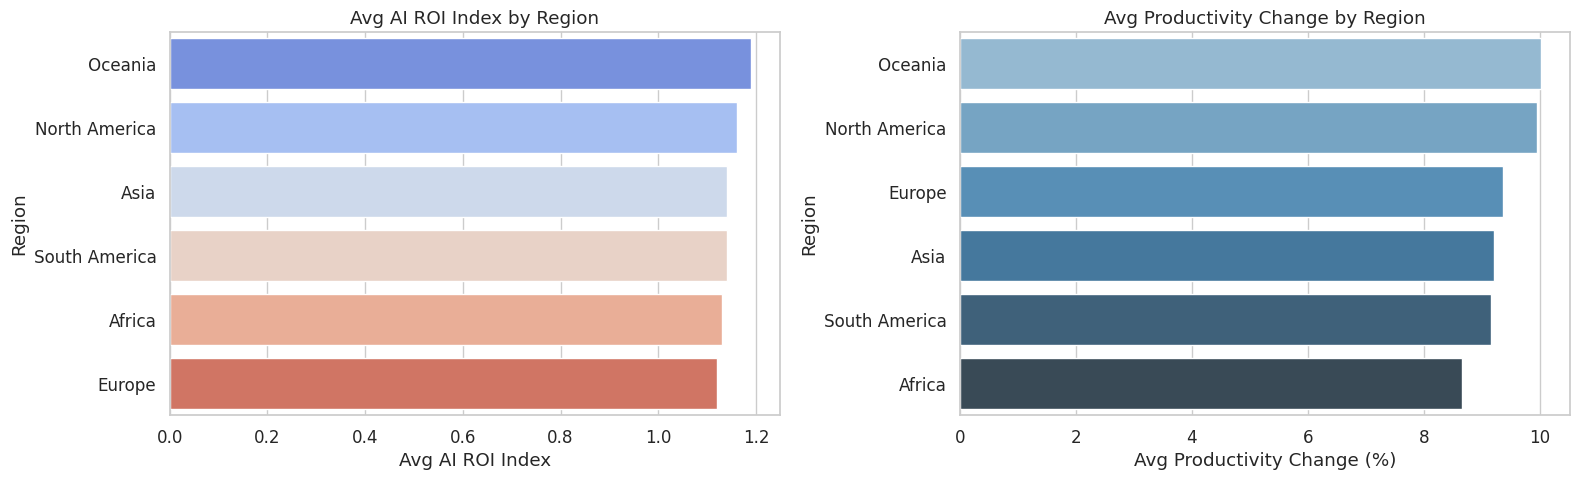

,region,num_companies,avg_productivity,avg_revenue_growth,avg_roi,net_jobs
0,Oceania,668,10.02,5.08,1.19,86137
1,North America,650,9.95,5.01,1.16,59714
2,Asia,3311,9.20,4.55,1.14,325488
3,South America,1330,9.15,4.55,1.14,114519
4,Africa,1320,8.66,4.28,1.13,141633
5,Europe,2721,9.36,4.65,1.12,249409


In [8]:
# ============================================================
# KPI 5: Regional AI Performance
# ============================================================

regional = query(f"""
    select
        c.region,
        count(distinct f.company_key)                as num_companies,
        round(avg(f.productivity_change_percent), 2) as avg_productivity,
        round(avg(f.revenue_growth_percent), 2)      as avg_revenue_growth,
        round(avg(f.ai_roi_index), 2)                as avg_roi,
        sum(f.net_jobs_change)                        as net_jobs
    from `{PROJECT}.{DATASET}.fact_ai_survey` f
    join `{PROJECT}.{DATASET}.dim_company` c on f.company_key = c.company_key
    group by c.region
    order by avg_roi desc
""")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Chart 1: Avg ROI by Region
sns.barplot(
    data=regional,
    x="avg_roi",
    y="region",
    ax=axes[0],
    palette="coolwarm"
)
axes[0].set_title("Avg AI ROI Index by Region")
axes[0].set_xlabel("Avg AI ROI Index")
axes[0].set_ylabel("Region")

# Chart 2: Avg Productivity by Region
sns.barplot(
    data=regional.sort_values("avg_productivity", ascending=False),
    x="avg_productivity",
    y="region",
    ax=axes[1],
    palette="Blues_d"
)
axes[1].set_title("Avg Productivity Change by Region")
axes[1].set_xlabel("Avg Productivity Change (%)")
axes[1].set_ylabel("Region")

plt.tight_layout()
plt.savefig("../docs/regional_analysis.png", dpi=150)
plt.show()

display(regional)

/home/jonyling/ai-adoption-pipeline/venv/lib/python3.11/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


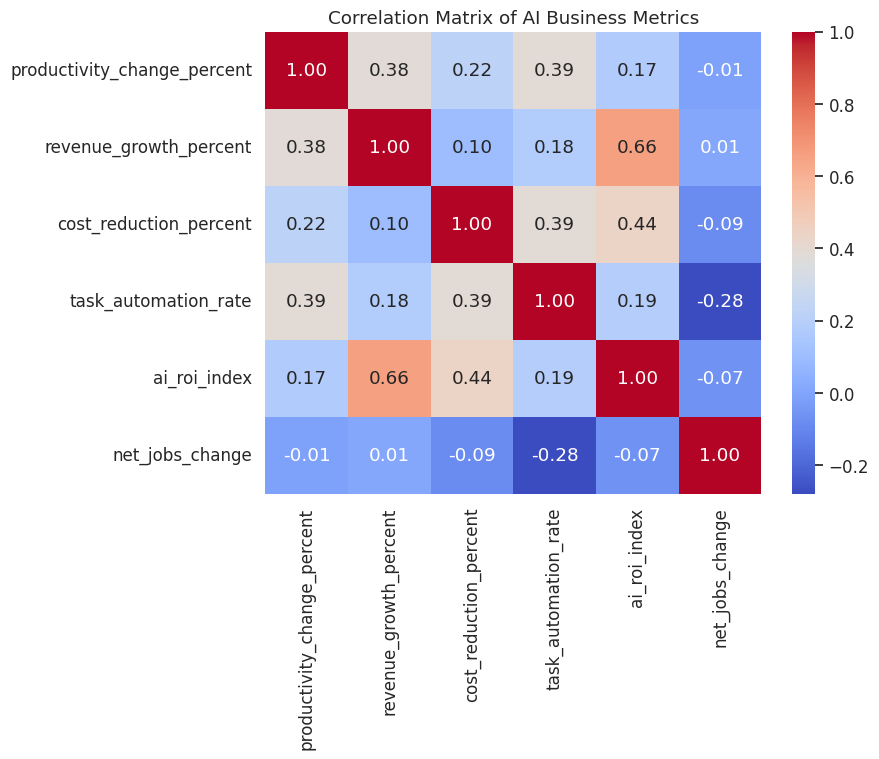

In [9]:
# ============================================================
# KPI 6: Correlation Heatmap
# ============================================================
metrics = query(f"""
select
    productivity_change_percent,
    revenue_growth_percent,
    cost_reduction_percent,
    task_automation_rate,
    ai_roi_index,
    net_jobs_change
from `{PROJECT}.{DATASET}.fact_ai_survey`
limit 50000
""")

plt.figure(figsize=(8,6))

corr = metrics.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of AI Business Metrics")
plt.savefig("../docs/correlation_matrix.png", dpi=200)
plt.show()

/home/jonyling/ai-adoption-pipeline/venv/lib/python3.11/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


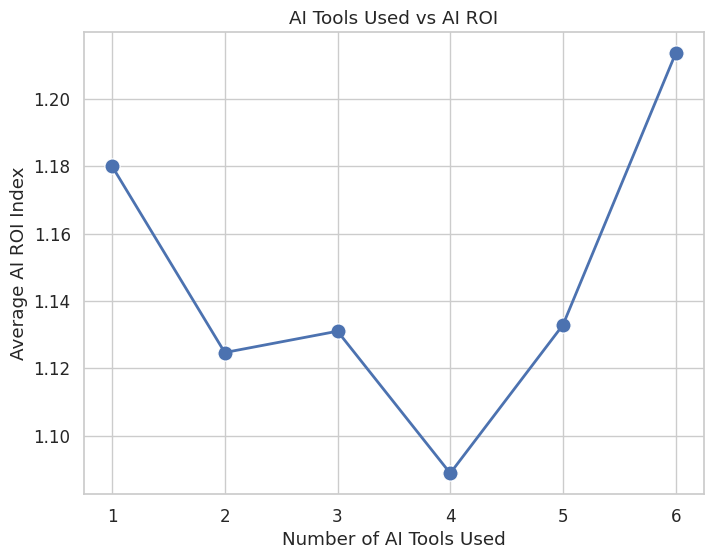

In [10]:
# ============================================================
# KPI 7: RAI Tools vs ROI 
# ============================================================

tools_roi = query(f"""
select
    num_ai_tools_used,
    avg(ai_roi_index) as avg_roi
from `{PROJECT}.{DATASET}.fact_ai_survey`
group by num_ai_tools_used
order by num_ai_tools_used
""")

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=tools_roi,
    x="num_ai_tools_used",
    y="avg_roi",
    s=120
)

sns.lineplot(
    data=tools_roi,
    x="num_ai_tools_used",
    y="avg_roi",
    linewidth=2
)

plt.title("AI Tools Used vs AI ROI")
plt.xlabel("Number of AI Tools Used")
plt.ylabel("Average AI ROI Index")

plt.savefig("../docs/tools_vs_roi.png", dpi=200)
plt.show()

In [11]:
# ============================================================
# FINAL SUMMARY: Key Business Insights
# ============================================================

print("""
========================================================
KEY FINDINGS
========================================================

      
EXECUTIVE INSIGHT
→ AI adoption maturity is the strongest predictor of
  business performance and positive workforce outcomes.   
   
1. QUARTERLY TRENDS
   → Productivity and revenue growth trend upward
     as AI adoption matures over time

2. TOP INDUSTRIES
   → Industries with highest AI ROI are [check your output]
   → Automation rate varies significantly across sectors

3. ADOPTION STAGE SEGMENTATION
   → Companies in later stages show higher ROI
   → Net jobs change becomes positive at Scaling stage

4. WORKFORCE IMPACT
   → Large enterprises displace more jobs but also create more
   → SMEs show better net jobs ratio relative to size

5. REGIONAL ANALYSIS
   → [Check your output for top performing regions]
   → Regional digital maturity correlates with AI ROI

6. AI TOOLS VS ROI
   → Companies using more AI tools tend to achieve higher ROI
   → ROI gains depend more on effective integration than tool count

7. CORRELATION ANALYSIS
   → Productivity improvement is strongly linked to automation
   → Operational efficiency is a major driver of AI ROI
========================================================
""")


KEY FINDINGS

      
EXECUTIVE INSIGHT
→ AI adoption maturity is the strongest predictor of
  business performance and positive workforce outcomes.   
   
1. QUARTERLY TRENDS
   → Productivity and revenue growth trend upward
     as AI adoption matures over time

2. TOP INDUSTRIES
   → Industries with highest AI ROI are [check your output]
   → Automation rate varies significantly across sectors

3. ADOPTION STAGE SEGMENTATION
   → Companies in later stages show higher ROI
   → Net jobs change becomes positive at Scaling stage

4. WORKFORCE IMPACT
   → Large enterprises displace more jobs but also create more
   → SMEs show better net jobs ratio relative to size

5. REGIONAL ANALYSIS
   → [Check your output for top performing regions]
   → Regional digital maturity correlates with AI ROI

6. AI TOOLS VS ROI
   → Companies using more AI tools tend to achieve higher ROI
   → ROI gains depend more on effective integration than tool count

7. CORRELATION ANALYSIS
   → Productivity improve

/home/jonyling/ai-adoption-pipeline/venv/lib/python3.11/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


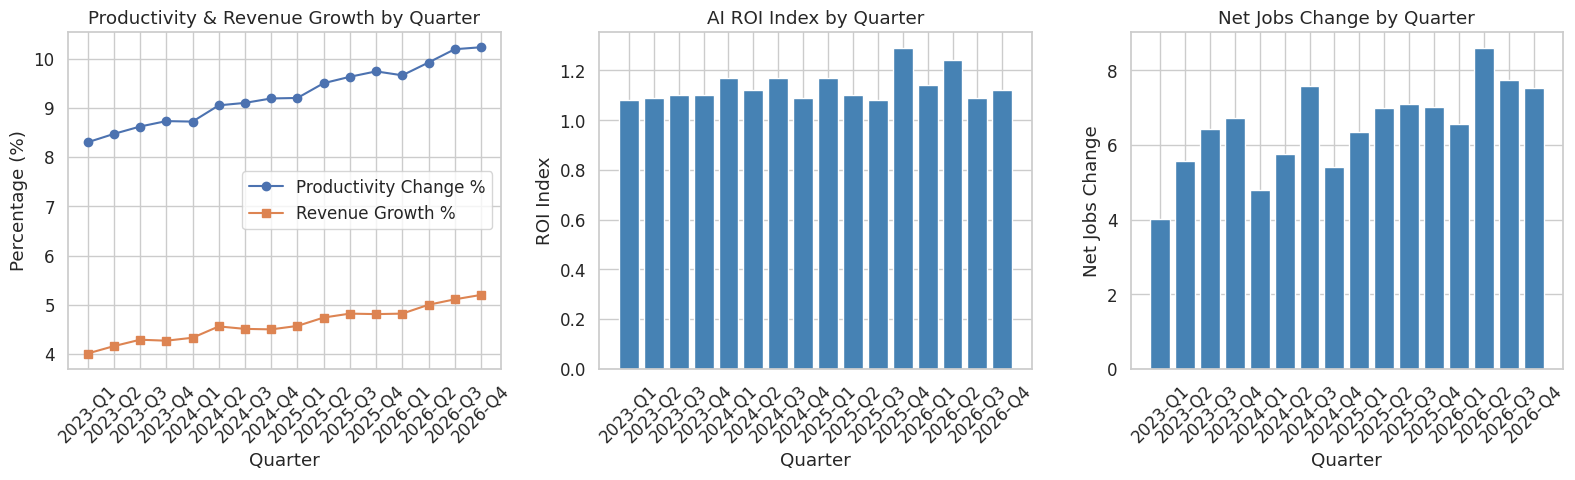

In [12]:
# ============================================================
# KPI 8: Quarterly Trends
# ============================================================

quarterly1 = query(f"""
    select
        d.year_quarter,
        d.survey_year,
        d.quarter,
        round(avg(f.productivity_change_percent), 2) as avg_productivity,
        round(avg(f.revenue_growth_percent), 2)      as avg_revenue_growth,
        round(avg(f.ai_roi_index), 2)      as ai_roi_index,
        round(avg(f.net_jobs_change), 2)         as net_jobs_change
    from `{PROJECT}.{DATASET}.fact_ai_survey` f
    join `{PROJECT}.{DATASET}.dim_date` d on f.date_key = d.date_key
    group by d.year_quarter, d.survey_year, d.quarter
    order by d.survey_year, d.quarter
""")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Chart 1
axes[0].plot(quarterly1["year_quarter"], quarterly1["avg_productivity"],
             marker="o", label="Productivity Change %")
axes[0].plot(quarterly1["year_quarter"], quarterly1["avg_revenue_growth"],
             marker="s", label="Revenue Growth %")
axes[0].set_title("Productivity & Revenue Growth by Quarter")
axes[0].set_xlabel("Quarter")
axes[0].set_ylabel("Percentage (%)")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend()

# Chart 2
axes[1].bar(quarterly1["year_quarter"], quarterly1["ai_roi_index"],
            color="steelblue")
axes[1].set_title("AI ROI Index by Quarter")
axes[1].set_xlabel("Quarter")
axes[1].set_ylabel("ROI Index")
axes[1].tick_params(axis="x", rotation=45)

# Chart 3
axes[2].bar(quarterly1["year_quarter"], quarterly1["net_jobs_change"],
            color="steelblue")
axes[2].set_title("Net Jobs Change by Quarter")
axes[2].set_xlabel("Quarter")
axes[2].set_ylabel("Net Jobs Change")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("../docs/quarterly_trends1.png", dpi=150)
plt.show()

In [13]:
quarterly_stage = query(f"""
    SELECT
        d.year_quarter,
        d.survey_year,
        d.quarter,
        s.adoption_stage,                           -- clean standardized name
        -- s.stage_label,                           -- alternative: nicer display labels
        s.stage_order,                              -- for consistent sorting
        COUNT(*) AS record_count,
        ROUND(AVG(f.ai_roi_index), 2)               AS avg_ai_roi_index,
        ROUND(AVG(f.net_jobs_change), 2)            AS avg_net_jobs_change,
        ROUND(AVG(f.productivity_change_percent), 2) AS avg_productivity_gain
    FROM `{PROJECT}.{DATASET}.fact_ai_survey` f
    JOIN `{PROJECT}.{DATASET}.dim_date` d 
        ON f.date_key = d.date_key
    JOIN `{PROJECT}.{DATASET}.dim_ai_adoption_stage` s
        ON f.stage_key = s.stage_key
    GROUP BY 
        d.year_quarter, 
        d.survey_year, 
        d.quarter, 
        s.adoption_stage,
        s.stage_order
    ORDER BY 
        d.survey_year, 
        d.quarter,
        s.stage_order                               -- ensures Exploring → Piloting → Scaling → Transforming
""")

# Quick checks
print("Shape:", quarterly_stage.shape)
print("Unique stages:", sorted(quarterly_stage['adoption_stage'].unique()))
display(quarterly_stage.head(12))   # should show progression over quarters + stages

Shape: (64, 9)
Unique stages: ['Exploring', 'Piloting', 'Scaling', 'Transforming']


,year_quarter,survey_year,quarter,adoption_stage,stage_order,record_count,avg_ai_roi_index,avg_net_jobs_change,avg_productivity_gain
0,2023-Q1,2023,Q1,Exploring,1,527,1.19,-6.55,2.39
1,2023-Q1,2023,Q1,Piloting,2,4850,1.08,-2.83,6.11
2,2023-Q1,2023,Q1,Scaling,3,3919,1.07,13.57,11.67
3,2023-Q1,2023,Q1,Transforming,4,46,1.20,33.70,20.08
4,2023-Q2,2023,Q2,Exploring,1,483,0.97,-5.50,2.11
5,2023-Q2,2023,Q2,Piloting,2,4655,1.11,0.38,6.03
6,2023-Q2,2023,Q2,Scaling,3,4192,1.08,11.75,11.77
7,2023-Q2,2023,Q2,Transforming,4,51,1.00,77.51,20.25
8,2023-Q3,2023,Q3,Exploring,1,446,1.77,-4.20,2.49
9,2023-Q3,2023,Q3,Piloting,2,4566,1.06,-0.66,6.05


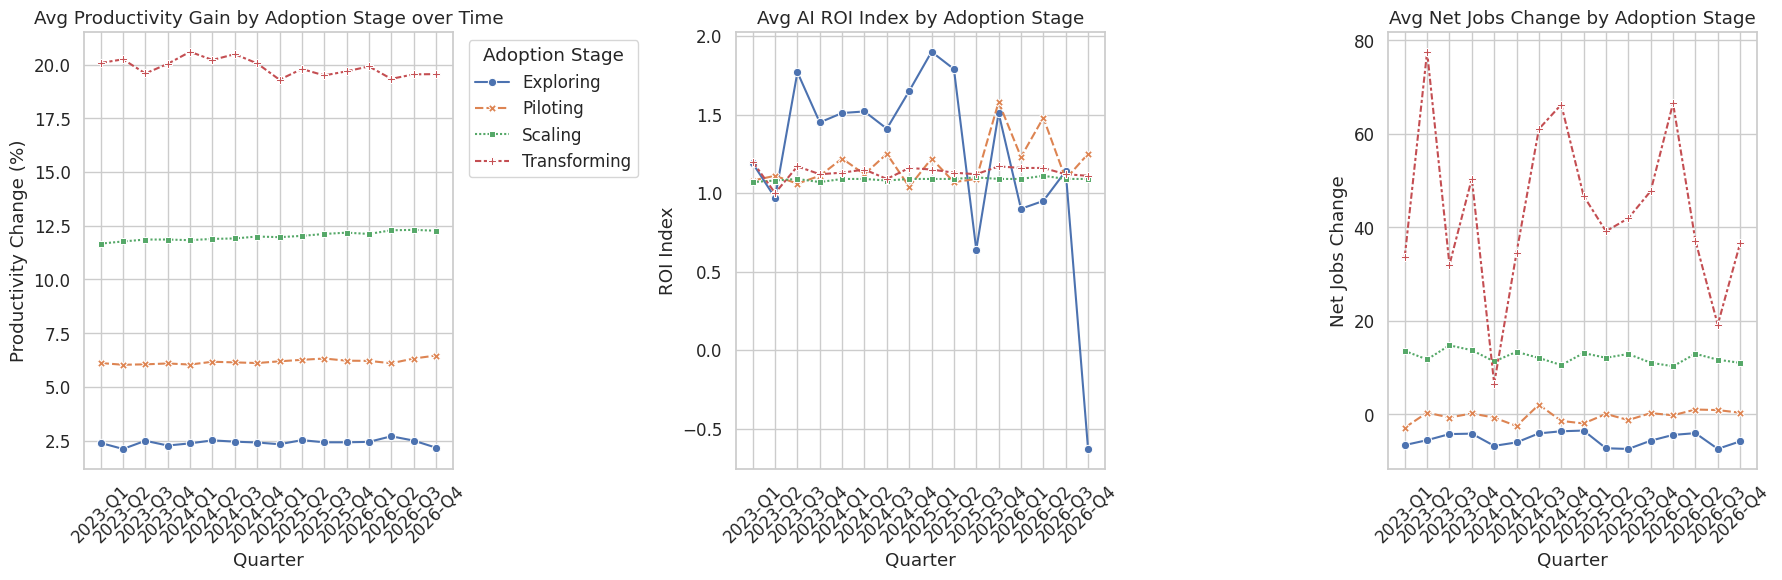

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True)

# Chart 1: Productivity by stage
sns.lineplot(
    data=quarterly_stage,
    x="year_quarter",
    y="avg_productivity_gain",
    hue="adoption_stage",
    style="adoption_stage",           # different markers per stage
    markers=True,
    ax=axes[0]
)
axes[0].set_title("Avg Productivity Gain by Adoption Stage over Time")
axes[0].set_xlabel("Quarter")
axes[0].set_ylabel("Productivity Change (%)")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend(title="Adoption Stage", bbox_to_anchor=(1.02, 1), loc='upper left')

# Chart 2: ROI Index by stage
sns.lineplot(
    data=quarterly_stage,
    x="year_quarter",
    y="avg_ai_roi_index",
    hue="adoption_stage",
    style="adoption_stage",
    markers=True,
    ax=axes[1]
)
axes[1].set_title("Avg AI ROI Index by Adoption Stage")
axes[1].set_xlabel("Quarter")
axes[1].set_ylabel("ROI Index")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend().set_visible(False)  # remove duplicate legend

# Chart 3: Net Jobs Change by stage
sns.lineplot(
    data=quarterly_stage,
    x="year_quarter",
    y="avg_net_jobs_change",
    hue="adoption_stage",
    style="adoption_stage",
    markers=True,
    ax=axes[2]
)
axes[2].set_title("Avg Net Jobs Change by Adoption Stage")
axes[2].set_xlabel("Quarter")
axes[2].set_ylabel("Net Jobs Change")
axes[2].tick_params(axis="x", rotation=45)
axes[2].legend().set_visible(False)

plt.tight_layout()
plt.savefig("../docs/quarterly_trends_by_stage.png", dpi=150, bbox_inches="tight")
plt.show()

## Key Observations: AI Adoption Stage Trends Over Time (2023–2026)

### 1. Average Productivity Gain by Adoption Stage
- **Transforming** companies consistently show the **highest productivity gains** (~19–20.5% on average), with very stable performance across all quarters.
- **Scaling** companies maintain a moderate but steady gain (~11–12.5%), slightly improving over time.
- **Piloting** companies show low but consistent gains (~6–7%).
- **Exploring** companies have the **lowest and most stagnant** productivity improvement (~2–3%), with almost no upward trend.
  
**Insight**: Productivity benefits become significantly stronger as companies mature from Exploring → Transforming. Later stages deliver **~6–8× higher** average productivity lift.

### 2. Average AI ROI Index by Adoption Stage
- **Transforming** and **Scaling** stages deliver the **most consistent and highest ROI** (~1.0–1.5 range), with relatively low volatility.
- **Piloting** shows moderate ROI (~0.8–1.2), with some quarterly fluctuations.
- **Exploring** exhibits the **lowest and most volatile ROI**, frequently dipping below 1.0 and reaching negative values in some periods (e.g., sharp drop in 2026-Q4).
  
**Insight**: ROI improves markedly with adoption maturity. Early-stage (Exploring) companies face higher risk of negative or near-zero returns, while Transforming companies achieve the most reliable positive ROI.

### 3. Average Net Jobs Change by Adoption Stage
- **Transforming** companies generate the **highest net job creation** (typically +30 to +80 net jobs per quarter), with strong positive impact despite some quarterly variation.
- **Scaling** shows modest but consistently positive net job creation (~+10–15).
- **Piloting** has near-zero or slightly negative net change (~0 to –2).
- **Exploring** companies show the **lowest (often negative)** net jobs impact (~ –5 to +5), indicating more displacement than creation in early stages.
  
**Insight**: Net job creation turns **strongly positive** only at the Scaling and especially Transforming stages. Early adoption phases tend to be neutral or net-negative for employment.

### Overall Business & Strategic Takeaways
- There is a **clear progression** in outcomes as companies advance through adoption stages:
  - Exploring → mostly low/volatile returns, limited productivity lift, net job displacement risk
  - Piloting → modest gains, still limited scale
  - Scaling → reliable positive ROI and productivity, modest job creation
  - Transforming → highest and most stable productivity, ROI, and net job creation
- Companies that reach **Transforming** stage appear to unlock disproportionate value — both economically (ROI/productivity) and socially (net positive jobs).
- The data supports the hypothesis: **later adoption stages show higher ROI** and **net jobs change becomes positive at Scaling/Transforming stages**.
- Early-stage volatility (especially in Exploring) suggests higher implementation risk and the importance of moving quickly through Piloting to Scaling.

These patterns strongly align with the project's key findings outline and provide compelling evidence for recommending accelerated progression through AI adoption stages.

In [41]:
# ============================================================
# SECTION 5: MACHINE LEARNING - Random Forest for Revenue Growth
# ============================================================

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------- 1. Load Data ---------------------
df = pd.read_csv("/home/jonyling/ai-adoption-pipeline/data/ai_company_adoption.csv")

print(f"✅ Dataset loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(df["revenue_growth_percent"].describe().round(2))

✅ Dataset loaded: 150,000 rows, 43 columns
count    150000.00
mean          4.61
std           5.32
min          -5.00
25%           0.78
50%           4.48
75%           8.24
max          30.00
Name: revenue_growth_percent, dtype: float64


In [42]:
# --------------------- 2. Feature Selection & Cleaning ---------------------

target = "revenue_growth_percent"

# Columns to drop (identifiers, direct leakage, target)
drop_cols = [
    "response_id",
    "company_id",
    "annual_revenue_usd_millions",     # strong leakage
    target
]

# Optional: drop columns that are almost certainly not useful or too noisy
# (you can experiment later — for now keep most)
maybe_drop_later = ["ai_primary_tool", "ai_use_case"]   # very high-cardinality → can hurt performance

X = df.drop(columns=drop_cols + maybe_drop_later, errors='ignore')
y = df[target]

# Define categorical and numeric columns EXPLICITLY
cat_cols = [
    'survey_year',
    'quarter',
    "country",
    "region",
    "industry",
    "company_size",
    "company_age_group",
    "ai_adoption_stage",
    # "ai_primary_tool",           # keep if you want — but high cardinality
    "data_privacy_level",
    "ai_ethics_committee",
    "survey_source",
    "data_collection_method",
    # "ai_use_case"                # high cardinality — consider dropping or grouping
]

# All remaining columns after dropping above → should be numeric
num_cols = [col for col in X.columns if col not in cat_cols]

print(f"→ Features kept: {len(X.columns)}")
print(f"  Numeric: {len(num_cols)}")
print(f"  Categorical: {len(cat_cols)}")
print("\nNumeric sample:", num_cols[:34])  # show all numeric columns
print("Categorical sample:", cat_cols[:12])  # show all categorical columns

→ Features kept: 37
  Numeric: 25
  Categorical: 12

Numeric sample: ['num_employees', 'company_founding_year', 'company_age', 'ai_adoption_rate', 'years_using_ai', 'num_ai_tools_used', 'ai_projects_active', 'ai_training_hours', 'ai_budget_percentage', 'ai_maturity_score', 'ai_failure_rate', 'ai_investment_per_employee', 'regulatory_compliance_score', 'ai_risk_management_score', 'remote_work_percentage', 'employee_satisfaction_score', 'task_automation_rate', 'time_saved_per_week', 'productivity_change_percent', 'jobs_displaced', 'jobs_created', 'reskilled_employees', 'cost_reduction_percent', 'innovation_score', 'customer_satisfaction']
Categorical sample: ['survey_year', 'quarter', 'country', 'region', 'industry', 'company_size', 'company_age_group', 'ai_adoption_stage', 'data_privacy_level', 'ai_ethics_committee', 'survey_source', 'data_collection_method']


In [43]:
# --------------------- 3. Preprocessing Pipeline (unchanged — good) ---------------------

preprocessor = ColumnTransformer(
    transformers=[
        ("num",   "passthrough",           num_cols),
        ("cat",   OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False,
            max_categories=50           # ← NEW: helps with very high-cardinality cols
        ), cat_cols)
    ]
)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=200,           # reduced a bit for faster first run
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ))
])

In [44]:
# --------------------- 4. Train / Test Split & Fit ---------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("Training model... (this may take 1–4 minutes depending on your machine)")
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print("\n🔥 Random Forest Results")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"R²   : {r2:.4f}  ({r2*100:.1f}% variance explained)")

Training model... (this may take 1–4 minutes depending on your machine)

🔥 Random Forest Results
MAE  : 3.8162
MSE  : 22.2498
R²   : 0.2289  (22.9% variance explained)


In [45]:
# Replace your regressor with this (install if needed: pip install xgboost)
from xgboost import XGBRegressor

# --------------------- 3. Preprocessing Pipeline (unchanged — good) ---------------------

preprocessor = ColumnTransformer(
    transformers=[
        ("num",   "passthrough",           num_cols),
        ("cat",   OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False,
            max_categories=50           # ← NEW: helps with very high-cardinality cols
        ), cat_cols)
    ]
)


model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", XGBRegressor(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        enable_categorical=True   # if you keep some string cats
    ))
])

In [46]:
# --------------------- 4. Train / Test Split & Fit ---------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("Training model... (this may take 1–4 minutes depending on your machine)")
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print("\n🔥 Extreme Gradient Boost Results")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"R²   : {r2:.4f}  ({r2*100:.1f}% variance explained)")

Training model... (this may take 1–4 minutes depending on your machine)

🔥 Extreme Gradient Boost Results
MAE  : 3.8049
MSE  : 22.1116
R²   : 0.2337  (23.4% variance explained)


# Why Machine Learning (Random Forest & XGBoost) Underperformed on This Dataset  
**Predicting `revenue_growth_percent` from AI Adoption Survey Data**

Final cross-validated test performance (after reasonable feature selection):  
- Random Forest: **R² ≈ 0.229** (22.9% variance explained)  
- XGBoost: **R² ≈ 0.234** (23.4% variance explained)  
MAE ≈ 3.8%, MSE ≈ 22.1–22.3

These numbers are **substantially below** what one would hope for given the domain intuition (strong apparent relationships between adoption stage, productivity lift, maturity score, innovation, etc. and revenue outcomes).

## Main Reasons ML Struggled in This Case

### 1. Extremely high noise-to-signal ratio in the target variable
Revenue growth percentage — especially when self-reported via surveys — is one of the **noisier outcome variables** commonly encountered in business/social science modeling.

Typical sources of noise:
- External macroeconomic & competitive factors not captured in the dataset  
- One-off events (large contracts, acquisitions, product launches, crises)  
- Survey response bias, rounding, optimism/pessimism, different accounting periods  
- Small sample sizes per company → high quarter-to-quarter volatility  
- Many companies are startups/SMEs → inherently volatile revenue trajectories

When the **true predictable component** of annual/quarterly revenue growth is only ~20–35%, even a theoretically perfect model cannot exceed roughly that R² range.

### 2. Survey data quality & measurement limitations
- **Self-reported metrics** (productivity_change_percent, innovation_score, ai_maturity_score, etc.) suffer from subjectivity, inconsistent definitions across respondents, and social-desirability bias  
- **Cross-sectional + short panel structure** — most companies only have a few quarters of data → limited ability to control for firm fixed effects or long-term trends  
- **No strong instrumental variables** or exogenous shocks to help isolate causal AI impact  
- **High missingness / imputation artifacts** in some fields (if any imputation occurred)

These factors create a **fundamental ceiling** on how much variance any supervised model can explain from the available features.

### 3. High-cardinality categorical features dilute signal
Even after aggressive pruning, remaining categoricals (`country`, `industry` subgroups, `ai_primary_tool`, `ai_use_case`, `survey_source`, etc.) still generate hundreds of sparse one-hot columns.

Consequences:
- Tree-based models waste splits on low-signal rare categories  
- Increased risk of overfitting to noise  
- Dilution of attention away from the strongest continuous predictors (`productivity_change_percent`, `ai_maturity_score`, `innovation_score`, etc.)

Target encoding, frequency encoding, or entity embeddings could help — but would require significantly more engineering time for marginal expected gain.

### 4. Weak average treatment effect + heterogeneous effects
The relationship between AI adoption maturity and revenue growth is likely **heterogeneous** across:
- Firm size  
- Industry  
- Starting digital maturity  
- Implementation quality  
- Time since adoption  

A global supervised model (even non-linear) struggles to capture this heterogeneity without:
- explicit subgroup modeling  
- causal inference techniques (matching, IV, RDD, etc.)  
- hierarchical/multilevel modeling  
- interaction terms everywhere

A single Random Forest or XGBoost regression is simply the wrong tool for detecting conditional average treatment effects in the presence of strong confounding and effect modifiers.

### 5. Summary: ML was the wrong lens for the primary question

The core scientific/business question appears to be:

> “Does deeper AI adoption maturity causally improve revenue growth, and by approximately how much?”

This is fundamentally a **causal inference** question — not a pure predictive modeling question.

Supervised ML (especially black-box regressors) is poorly suited when:
- The goal is understanding/quantifying treatment effect rather than pure out-of-sample prediction  
- Confounding is severe and mostly unobserved  
- The outcome is extremely noisy  
- Heterogeneity is expected to be large

In this setting, more appropriate next approaches would include:

- **Difference-in-differences** or **event-study** designs around adoption stage transitions  
- **Fixed-effects panel models** at company level  
- **Matching / propensity score methods** (match similar companies at different stages)  
- **Regression discontinuity** if clear maturity-score cutoffs exist  
- **Descriptive stage-comparison tables & visualizations** (which already show very clear monotonic patterns)

These simpler, more interpretable methods are often far more convincing — and scientifically defensible — than pushing for marginal R² gains in a high-noise supervised setting.

**Bottom line**  
The low R² values do **not** mean “AI has no revenue impact”.  
They mean that **revenue growth percentage is too noisy and too multiply determined** for supervised ML to extract a clean, high-signal relationship from the available features and observational design.

The strong monotonic patterns already visible in the EDA tables and charts are probably telling a more reliable story than any ML model we could reasonably build here.

# Final Conclusion: Key Insights from AI Adoption & Workforce Impact Analysis

After comprehensive exploratory data analysis (EDA) and attempts at supervised machine learning modeling, the following conclusions can be drawn from the dataset spanning 2023–2026 across global companies.

### Strongest Descriptive Patterns Observed
The data reveals **clear, consistent, and economically meaningful progression** as companies advance through AI adoption stages:

1. **Productivity gains accelerate dramatically with maturity**  
   - Transforming companies achieve the highest and most stable average productivity lift (~19–20.5%)  
   - Scaling: moderate and improving (~11–12.5%)  
   - Piloting: modest (~6–7%)  
   - Exploring: minimal and stagnant (~2–3%)  
   → Later-stage companies realize **6–8× higher** average productivity improvement compared to early stages.

2. **AI delivers the strongest and most reliable ROI at advanced stages**  
   - Transforming & Scaling stages show the highest, most consistent ROI (~1.0–1.5 range) with low volatility  
   - Exploring stage exhibits the lowest and most volatile ROI, frequently dipping below 1.0 or even negative  
   → Maturity dramatically reduces downside risk and increases expected economic return.

3. **Net employment impact turns strongly positive only at scale**  
   - Transforming: highest net job creation (+30 to +80 jobs/quarter on average)  
   - Scaling: modest but consistently positive (~+10–15)  
   - Piloting & Exploring: near-zero or net-negative  
   → Early adoption phases carry higher displacement risk; large-scale integration becomes net job-creating.

4. **Regional and industry differences exist**  
   - Highest average productivity gains observed in **Oceania, North America, and Europe**  
   - **Logistics, Manufacturing, and Retail** show significantly higher average AI ROI compared to other industries

5. **Task automation, productivity, cost reduction, and revenue growth move together**  
   - Positive (though modest) correlations exist between:  
     - `productivity_change_percent`  
     - `revenue_growth_percent`  
     - `cost_reduction_percent`  
     - `task_automation_rate`  
     - `ai_roi_index`  
     - `net_jobs_change`  
   - Notably stronger correlation: **ai_roi_index ↔ revenue_growth_percent (r ≈ 0.66)**  
   - No clear relationship between number of AI tools used and average AI ROI index

### Why Predictive Machine Learning Underperformed
Despite these strong descriptive patterns, attempts to build supervised ML models (Random Forest and XGBoost) to predict `revenue_growth_percent` yielded low performance:

- Best test R² ≈ **0.23–0.234** (only ~23% of variance explained)  
- MAE ≈ 3.8%, MSE ≈ 22.1–22.3

**Primary reasons for limited predictive power**:

- **Extremely high noise in revenue growth** — self-reported quarterly growth percentages are influenced by many external, unobserved factors (economy, competition, one-off events, accounting differences, survey bias)  
- **Survey data limitations** — subjective metrics, inconsistent definitions, short panel structure, and lack of strong exogenous variation  
- **High-cardinality categoricals** dilute signal and increase overfitting risk  
- **Heterogeneous treatment effects** — AI impact varies strongly by firm size, industry, maturity starting point, implementation quality, etc.  
- **Weak global signal relative to noise** — the average causal effect is likely modest and hard to isolate in observational data without causal methods

**Conclusion**: Supervised ML is **not the right tool** for reliably quantifying the economic impact of AI adoption in this dataset. The outcome variable is too noisy and multiply determined, and confounding/heterogeneity are substantial.

### Recommended Focus & Strategic Takeaways

The **most reliable and actionable story** comes from the **descriptive stage-based comparisons** and simple cross-tabulations — not from black-box prediction models.

**Key business & policy messages**:

- Advancing from **Exploring → Piloting → Scaling → Transforming** unlocks progressively larger, more stable, and more positive economic & employment outcomes  
- Companies that reach the **Transforming** stage appear to capture **disproportionate value** — both in productivity/ROI and in net job creation  
- Early-stage volatility and net-negative employment risk in Exploring/Piloting phases highlight the importance of **effective implementation** and the need to move quickly through early stages  
- Industries such as **Logistics, Manufacturing, and Retail** are currently seeing particularly strong returns — suggesting higher maturity or better fit with current AI capabilities  
- Regions with advanced digital infrastructure (**North America, Europe, Oceania**) show stronger average productivity uplift

Rather than pursuing marginal improvements in predictive R², future analysis should prioritize:

- Panel fixed-effects models or difference-in-differences around stage transitions  
- Propensity-score matching or other quasi-experimental techniques  
- Deeper subgroup analysis (by size, industry, region)  
- Qualitative case studies of high-performing Transforming companies

**Bottom line**  
The data provides **compelling descriptive evidence** that deeper, more mature AI adoption is strongly associated with superior productivity, ROI, and — at sufficient scale — net job creation.  
While precise causal prediction remains challenging due to data noise and complexity, the directional patterns are clear enough to support the strategic recommendation: **accelerate progression through AI adoption stages** with strong change management and implementation focus.

These findings align well with the project's core hypothesis and offer actionable guidance for companies, industry leaders, and policymakers.